# script to calculate the absolute coordinates of head position measured with DLC from center coordinates
(excluded worms from june head position has more oordinates then center stage)

In [1]:
#Importing the toolbox (takes several seconds)
import pandas as pd
from pathlib import Path
import numpy as np
import os
import matplotlib.pyplot as plt
import tifffile as tiff
from natsort import natsorted
import glob

In [2]:
from coordinate_conversion_functions import *
from track_plotting_functions import *

In [3]:
import matplotlib
matplotlib.matplotlib_fname()

'/users/daniel.mitic/.conda/envs/openCV/lib/python3.7/site-packages/matplotlib/mpl-data/matplotlibrc'

## read in data

In [4]:
#this are the center coordinates
path_center_coords='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_tracks/2020-07-01_14-41-11_chemotaxisl_worm2-TablePosRecord.txt'
df_center_coords=pd.read_csv(path_center_coords)
df_center_coords

,time,xc,x,yc,y
0,14:41:11.143,x,25.9866,y,15.1372
1,14:41:13.030,x,25.8373,y,15.1046
2,14:41:13.030,x,25.8373,y,15.1046
3,14:41:13.030,x,25.8373,y,15.1046
4,14:41:13.045,x,25.8372,y,15.1046
...,...,...,...,...,...
199997,15:01:13.037,x,10.4834,y,25.6223
199998,15:01:13.037,x,10.4834,y,25.6224
199999,15:01:13.054,x,10.4833,y,25.6224
200000,15:01:13.054,x,10.4833,y,25.6224


In [5]:
#this are the head and tail positions measured via dlc
path_head_tail='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-07-01_14-41-11_chemotaxisl_worm2-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5'
df_head_tail_coords=pd.read_hdf(path_head_tail, low_memory=False)
df_head_tail_coords

scorer    DLC_resnet50_HeadTailAug10shuffle1_275000                         \
bodyparts                                      Head                          
coords                                            x           y likelihood   
0                                        465.169281  269.800568   0.998680   
1                                        466.044525  269.976379   0.996693   
2                                        466.081451  270.645691   0.996747   
3                                        466.118866  270.800018   0.996742   
4                                        466.118866  271.347626   0.997057   
...                                             ...         ...        ...   
199996                                   365.600525  466.678802   0.995603   
199997                                   365.600525  466.678802   0.994918   
199998                                   365.600525  466.678802   0.996861   
199999                                   365.582092  466.541626   0.996067   
200000                                   365.414673  466.541626   0.997041   

scorer                                        
bodyparts        Tail                         
coords              x           y likelihood  
0          133.465485  291.106323   0.997892  
1          134.860123  291.197845   0.997678  
2          134.860123  291.394623   0.997300  
3          134.860123  291.432281   0.997369  
4          134.860123  291.455048   0.997470  
...               ...         ...        ...  
199996     270.733276  146.308167   0.996622  
199997     270.713409  146.308167   0.995165  
199998     270.693573  146.272430   0.996229  
199999     270.693573  146.158752   0.996279  
200000     270.674957  145.899628   0.994360  

[200001 rows x 6 columns]

# get absolute head and tail coordinates

In [6]:
scorer=df_head_tail_coords.columns.get_level_values(0)[0] # defines scorer as the first column of the dataframe\n",
df_head_tail_center_coords=df_center_coords
df_head_tail_center_coords=df_head_tail_center_coords.rename(columns = {'x': 'x_center',
                'y': 'y_center'}, inplace = False)
df_head_tail_center_coords=df_head_tail_center_coords[0:200001]
df_head_tail_center_coords

,time,xc,x_center,yc,y_center
0,14:41:11.143,x,25.9866,y,15.1372
1,14:41:13.030,x,25.8373,y,15.1046
2,14:41:13.030,x,25.8373,y,15.1046
3,14:41:13.030,x,25.8373,y,15.1046
4,14:41:13.045,x,25.8372,y,15.1046
...,...,...,...,...,...
199996,15:01:13.037,x,10.4834,y,25.6222
199997,15:01:13.037,x,10.4834,y,25.6223
199998,15:01:13.037,x,10.4834,y,25.6224
199999,15:01:13.054,x,10.4833,y,25.6224


In [7]:
#defining the parameters for the function to calulate the corrected head and tail positions
px_mm=0.00325 # this value represents how much mm is one pixel
x_lenght_frame=608 #lenght of x axis in frame (measured with fiji)
y_width_frame=610 #width of the y axis in frame
center_x=df_head_tail_center_coords['x_center'] #absolute coordinates of center position x
center_y=df_head_tail_center_coords['y_center'] #absolute coordinates of center position y
data_head_x=df_head_tail_coords[scorer]['Head']['x'].values #getting the x position of head
data_head_y=df_head_tail_coords[scorer]['Head']['y'].values #getting the y position of head
data_tail_x=df_head_tail_coords[scorer]['Tail']['x'].values #getting the x position of tail
data_tail_y=df_head_tail_coords[scorer]['Tail']['y'].values #getting the y position of tail

In [8]:
#create absolute coordinates for head
corrected_head_position=corrected_absolute_coordinates(center_x,center_y,data_head_x,
                data_head_y,px_mm,y_width_frame,x_lenght_frame)

corrected_head_position= corrected_head_position.rename(columns = {'x_corrected': 'x_head_corrected',
                'y_corrected': 'y_head_corrected'}, inplace = False)

corrected_tail_position=corrected_absolute_coordinates(center_x,center_y,data_tail_x,
                                                       data_tail_y,px_mm,y_width_frame,x_lenght_frame)
#create absolute coordinates for tail
corrected_tail_position= corrected_tail_position.rename(columns = {'x_corrected': 'x_tail_corrected',
                'y_corrected': 'y_tail_corrected'}, inplace = False)

In [9]:
#joining dfs for center coords and corrected head and tail coordinates
df_head_tail_center_coords = pd.concat([df_head_tail_center_coords,corrected_head_position, 
                                        corrected_tail_position], axis=1)
df_head_tail_center_coords

,time,xc,x_center,yc,y_center,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected
0,14:41:11.143,x,25.9866,y,15.1372,25.462800,15.022802,26.540837,15.092046
1,14:41:13.030,x,25.8373,y,15.1046,25.310655,14.990773,26.387005,15.059743
2,14:41:13.030,x,25.8373,y,15.1046,25.310535,14.992948,26.387005,15.060383
3,14:41:13.030,x,25.8373,y,15.1046,25.310414,14.993450,26.387005,15.060505
4,14:41:13.045,x,25.8372,y,15.1046,25.310314,14.995230,26.386905,15.060579
...,...,...,...,...,...,...,...,...,...
199996,15:01:13.037,x,10.4834,y,25.6222,10.283198,26.147656,10.591517,25.106452
199997,15:01:13.037,x,10.4834,y,25.6223,10.283198,26.147756,10.591581,25.106552
199998,15:01:13.037,x,10.4834,y,25.6224,10.283198,26.147856,10.591646,25.106535
199999,15:01:13.054,x,10.4833,y,25.6224,10.283158,26.147410,10.591546,25.106166


In [10]:
#corrected for food position
xref=10.5
df_head_tail_center_coords['x_tail_corrected']=df_head_tail_center_coords['x_tail_corrected']-xref
df_head_tail_center_coords['x_head_corrected']=df_head_tail_center_coords['x_head_corrected']-xref
df_head_tail_center_coords['x_center']=df_head_tail_center_coords['x_center']-xref
df_head_tail_center_coords

,time,xc,x_center,yc,y_center,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected
0,14:41:11.143,x,15.4866,y,15.1372,14.962800,15.022802,16.040837,15.092046
1,14:41:13.030,x,15.3373,y,15.1046,14.810655,14.990773,15.887005,15.059743
2,14:41:13.030,x,15.3373,y,15.1046,14.810535,14.992948,15.887005,15.060383
3,14:41:13.030,x,15.3373,y,15.1046,14.810414,14.993450,15.887005,15.060505
4,14:41:13.045,x,15.3372,y,15.1046,14.810314,14.995230,15.886905,15.060579
...,...,...,...,...,...,...,...,...,...
199996,15:01:13.037,x,-0.0166,y,25.6222,-0.216802,26.147656,0.091517,25.106452
199997,15:01:13.037,x,-0.0166,y,25.6223,-0.216802,26.147756,0.091581,25.106552
199998,15:01:13.037,x,-0.0166,y,25.6224,-0.216802,26.147856,0.091646,25.106535
199999,15:01:13.054,x,-0.0167,y,25.6224,-0.216842,26.147410,0.091546,25.106166


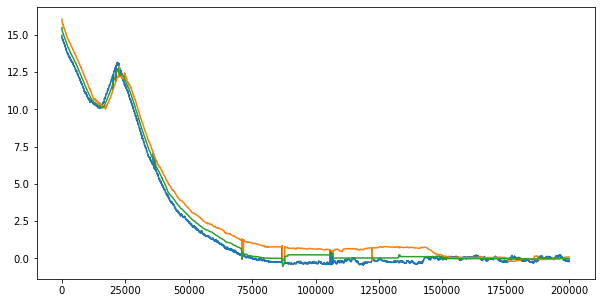

In [11]:
#x positition of vs time
x=np.arange(200001)
head_pos_x=df_head_tail_center_coords['x_head_corrected']
tail_pos_x=df_head_tail_center_coords['x_tail_corrected']
x_center_pos=df_head_tail_center_coords['x_center']

fig3, ax3 = plt.subplots(1,1, figsize = (10,5))
ax3.plot(x,head_pos_x,label="head")
ax3.plot(x,tail_pos_x,label="tail")
ax3.plot(x,x_center_pos,label="center")

In [12]:
print(away_from_food['x_head_corrected'].min())
print(away_from_food['x_head_corrected'].max())


NameError: name 'away_from_food' is not defined

# calculate and plot concentration change

In [ ]:
#this is telling you the concentration of every x position occuring in the data
#since it is a stripe assay only the x coordinates matter for concentration change
#parameters determined via the curve fit script
L=1
x0=3.81953189
k=-0.69421567
b=0
x_head_corrected=df_head_tail_center_coords['x_head_corrected'].values #xref adust gradient for food position
x_tail_corrected=df_head_tail_center_coords['x_tail_corrected'].values
x_center=df_head_tail_center_coords['x_center'].values
y_fit_head=sigmoid(x_head_corrected, L, x0, k, b)
y_fit_tail=sigmoid(x_tail_corrected, L, x0, k, b)
y_fit_center=sigmoid(x_center, L, x0, k, b)

In [ ]:
#creating df with x head/tail position and the corresponding concentration
position_concentration = pd.DataFrame(data=x_head_corrected,columns=["x_head_corrected"])
position_concentration['x_tail_corrected']=pd.DataFrame(data=x_tail_corrected,columns=["x_tail_corrected"])
position_concentration['x_center']=pd.DataFrame(data=x_center,columns=["x_center"])
position_concentration['concentration_head']=y_fit_head
position_concentration['concentration_tail']=y_fit_tail
position_concentration['concentration_center']=y_fit_center
position_concentration

In [ ]:
#calculating concentration change
concentration_change=position_concentration
concentration_change["concentration_change_head"] = position_concentration["concentration_head"].diff()
concentration_change["concentration_change_tail"] = position_concentration["concentration_tail"].diff()
concentration_change["concentration_change_center"] = position_concentration["concentration_center"].diff()
concentration_change

In [ ]:
figsize_x=10
figsize_y=45
line_width=0.5

#plot track
head_pos_x=df_head_tail_center_coords['x_head_corrected']
tail_pos_x=df_head_tail_center_coords['x_tail_corrected']
center_pos_x=df_head_tail_center_coords['x_center']

head_pos_y=df_head_tail_center_coords['y_head_corrected']
tail_pos_y=df_head_tail_center_coords['y_tail_corrected']
center_pos_y=df_head_tail_center_coords['y_center']

#fig3, ax3 = plt.subplots(1,1, figsize = (figsize_x,figsize_y), dpi=600)
#ax3.plot(head_pos_x,head_pos_y,linewidth=line_width)
#ax3.plot(tail_pos_x,tail_pos_y,linewidth=line_width)
#ax3.plot(center_pos_x,center_pos_y,linewidth=line_width)
#ax3.axvline(x=0, ymin=0, ymax=1, lw=10, alpha=.5, color='y')

#plt.show()

In [ ]:
#plot track with colorcoded concentration change
head_conc=concentration_change['concentration_head']
tail_conc=concentration_change['concentration_tail']
center_conc=concentration_change['concentration_center']

head_pos_x=df_head_tail_center_coords['x_head_corrected']
tail_pos_x=df_head_tail_center_coords['x_tail_corrected']
center_pos_x=df_head_tail_center_coords['x_center']

head_pos_y=df_head_tail_center_coords['y_head_corrected']
tail_pos_y=df_head_tail_center_coords['y_tail_corrected']
center_pos_y=df_head_tail_center_coords['y_center']

fig3, ax3 = plt.subplots(1,1, figsize = (10,5), dpi=600)
ax3.scatter(head_pos_x,head_pos_y,c=head_conc,s=0.01)
ax3.scatter(tail_pos_x,tail_pos_y,c=tail_conc,s=0.01)
ax3.scatter(center_pos_x,center_pos_y,c=center_conc,s=0.01)
ax3.axvline(x=0, ymin=0, ymax=1, lw=10, alpha=.5, color='y')

plt.show()



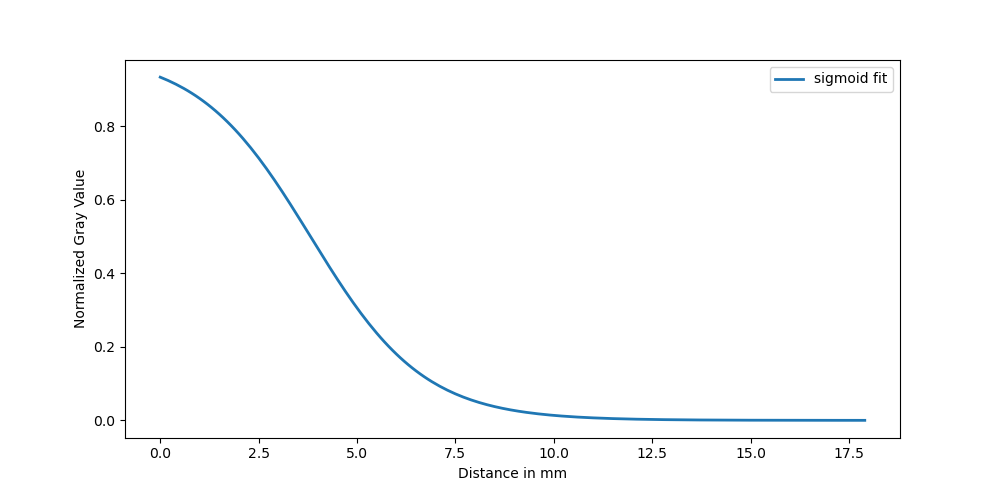

In [ ]:
#concentraton_change and time
x=np.arange(200001)
head_conc=concentration_change['concentration_change_head']
tail_conc=concentration_change['concentration_change_tail']
center_conc=concentration_change['concentration_change_center']

head_pos_x=df_head_tail_center_coords['x_head_corrected']
tail_pos_x=df_head_tail_center_coords['x_tail_corrected']
center_pos_x=df_head_tail_center_coords['x_center']

#xfig3, ax3 = plt.subplots(1,1, figsize = (10,5), dpi=600)
#ax3.plot(x,head_conc,label="head")
#ax3.plot(x,tail_conc,label="tail")
#ax3.plot(x,center_conc,label="center")

#plt.show()

In [ ]:
#concentraton and time
x=np.arange(200001)
head_conc=concentration_change['concentration_head']
tail_conc=concentration_change['concentration_tail']
center_conc=concentration_change['concentration_center']

head_pos_x=df_head_tail_center_coords['x_head_corrected']
tail_pos_x=df_head_tail_center_coords['x_tail_corrected']
center_pos_x=df_head_tail_center_coords['x_center']

xfig3, ax3 = plt.subplots(1,1, figsize = (10,5), dpi=600)
ax3.plot(x,head_conc,label="head")
ax3.plot(x,tail_conc,label="tail")
ax3.plot(x,center_conc,label="center")

#plt.show()

In [ ]:
#defining the parameters for the function to calulate the corrected head and tail positions
px_mm=0.00325 # this value represents how much mm is one pixel
x_lenght_frame=608 #lenght of x axis in frame (measured with fiji)
y_width_frame=610 #width of the y axis in frame

In [6]:
path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/all_x_refs.csv'
all_x_ref=pd.read_csv(path)
all_x_ref

,name,x_ref
0,2020-07-01_10-10-48_control_worm1-TablePosReco...,7.64
1,2020-07-01_10-50-18_control_worm2-TablePosReco...,7.64
2,2020-07-01_11-50-53_control_worm3-TablePosReco...,7.64
3,2020-07-01_13-21-00_chemotaxisl_worm1-TablePos...,9.00
4,2020-07-01_14-41-11_chemotaxisl_worm2-TablePos...,10.50
5,2020-07-01_15-13-35_chemotaxisl_worm3-TablePos...,8.10
6,2020-07-01_15-42-06_chemotaxisl_worm4-TablePos...,7.80
7,2020-07-01_16-20-36_chemotaxisl_worm5-TablePos...,6.60
8,2020-07-01_17-01-27_chemotaxis_worm6-TablePosR...,9.10
9,2020-07-01_17-32-12_control_worm4-TablePosReco...,7.64


In [ ]:
#loop to create csv with absolute heasd and tail coordinates + correction for xref
path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/'
all_x_ref=pd.read_csv('/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/all_x_refs.csv')
for i, folder in enumerate(natsorted(os.listdir(path))):   
    x_ref=all_x_ref['x_ref'][i] 
    #print(i, ': x ref of ', folder, 'is: ', x_ref)
    hdf5_files=glob.glob(os.path.join(path,folder,'*.h5'))
    txt_files=glob.glob(os.path.join(path,folder,'*.txt'))
    #acces the first (and should be only hdf5 file)
    hdf5_file=hdf5_files[0]
    df_head_tail=pd.read_hdf(hdf5_file)
    #print(df_head_tail)
    scorer= df_head_tail.columns.get_level_values(0)[0]
    data_head_x= df_head_tail[scorer]['Head']['x'].values #getting the x position of head
    data_head_y=df_head_tail[scorer]['Head']['y'].values #getting the y position of head
    data_tail_x=df_head_tail[scorer]['Tail']['x'].values #getting the x position of tail
    data_tail_y=df_head_tail[scorer]['Tail']['y'].values #getting the y position of tail
    txt_file=txt_files[0]
    df_center_coords=pd.read_csv(txt_file)
    #print(df_center_coords)
    if len(df_center_coords) > len(df_head_tail):
        rows_diff=len(df_center_coords) - len(df_head_tail)
        print(txt_files,'is',rows_diff,' rows longer')
        df_center_coords.drop(df_center_coords.tail(rows_diff).index,inplace=True)
    df_center_coords = df_center_coords[0:200001] #some center coordinates have more rows than dlc data
    #print(df_center_coords)
    df_center_coords = df_center_coords.rename(columns={"x":"x_center"})
    df_center_coords = df_center_coords.rename(columns={"y":"y_center"})
    #print(df_center_coords)
    center_x=df_center_coords['x_center'].values #absolute coordinates of center position x
    center_y=df_center_coords['y_center'].values #absolute coordinates of center position y
    #print(df_head_tail)
    corrected_head=corrected_absolute_coordinates(center_x,center_y,data_head_x, data_head_y,px_mm,y_width_frame,x_lenght_frame)  #fucntion to calculate absolute x coordinates for head and tial
    corrected_tail=corrected_absolute_coordinates(center_x,center_y,data_tail_x,data_tail_y,px_mm,y_width_frame,x_lenght_frame)
    corrected_head = corrected_head.rename(columns={"x_corrected":"x_head_corrected"}) #rename to have differnt column names for head and tail when the df is put togeether
    corrected_head = corrected_head.rename(columns={"y_corrected":"y_head_corrected"})
    corrected_tail = corrected_tail.rename(columns={"x_corrected":"x_tail_corrected"})
    corrected_tail = corrected_tail.rename(columns={"y_corrected":"y_tail_corrected"})
    df_head_tail_center_coords=pd.concat([df_center_coords,corrected_head,corrected_tail], axis=1)
    df_head_tail_center_coords['x_head_corrected']=df_head_tail_center_coords['x_head_corrected']-x_ref  #correcting for xref
    df_head_tail_center_coords['x_tail_corrected']=df_head_tail_center_coords['x_tail_corrected']-x_ref
    df_head_tail_center_coords['x_center']=df_head_tail_center_coords['x_center']-x_ref
    #print(df_head_tail_center_coords)
    #df_head_tail_center_coords.to_csv('/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/'+folder+'.csv')

In [ ]:
figsize_x=10
figsize_y=5
line_width=0.5
path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected/'
#plot all tracks for center head and tail
for filename in natsorted(os.listdir(path)):
    plot_tracks_center_head_tail(path+filename,figsize_x,figsize_y,line_width)
    plt.title(filename)
    plt.xlabel('X position')
    plt.ylabel('Y posiiton')
    plt.savefig(path+filename+'.png')

In [ ]:
#x positition/time all worms
path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected/'
figsize_x=10
figsize_y=5
line_width=0.5
x=np.arange(200001)

for filename in natsorted(os.listdir(path)):
    df_head_tail_center_coords=pd.read_csv(path+filename)
    head_pos_x=df_head_tail_center_coords['x_head_corrected']
    tail_pos_x=df_head_tail_center_coords['x_tail_corrected']
    x_center_pos=df_head_tail_center_coords['x_center']
    
    fig3, ax3 = plt.subplots(1,1, figsize = (figsize_x,figsize_y), dpi=600)
    ax3.plot(x,head_pos_x,label="head",linewidth=line_width)
    ax3.plot(x,tail_pos_x,label="tail",linewidth=line_width)
    ax3.plot(x,x_center_pos,label="center",linewidth=line_width)
    plt.xlabel('time')
    plt.ylabel('X posiiton')
    plt.legend()
    plt.title(filename)
    plt.ylim(-5,40)
    #plt.savefig(path+filename+'.png')

# calculate and plot concentration change for all worms

In [ ]:
#this is telling you the concentration of every x position occuring in the data
#since it is a stripe assay only the x coordinates matter for concentration change
#parameters determined via the curve fit script
L=1
x0=3.81953189
k=-0.69421567
b=0

In [ ]:
#creates csv files with concentration data
path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected/'
for filename in natsorted(os.listdir(path)):
    df_head_tail_center_coords=pd.read_csv(path+filename)
    x_head_corrected=df_head_tail_center_coords['x_head_corrected'].values #xref adust gradient for food position
    x_tail_corrected=df_head_tail_center_coords['x_tail_corrected'].values
    x_center=df_head_tail_center_coords['x_center'].values
    y_fit_head=sigmoid(x_head_corrected, L, x0, k, b)
    y_fit_tail=sigmoid(x_tail_corrected, L, x0, k, b)
    y_fit_center=sigmoid(x_center, L, x0, k, b)
    #creating df with x head/tail position and the corresponding concentration
    position_concentration = pd.DataFrame(data=x_head_corrected,columns=["x_head_corrected"])
    position_concentration['x_tail_corrected']=pd.DataFrame(data=x_tail_corrected,columns=["x_tail_corrected"])
    position_concentration['x_center']=pd.DataFrame(data=x_center,columns=["x_center"])
    position_concentration['concentration_head']=y_fit_head
    position_concentration['concentration_tail']=y_fit_tail
    position_concentration['concentration_center']=y_fit_center
    #calculating concentration change
    concentration_change=position_concentration
    concentration_change["concentration_change_head"] = position_concentration["concentration_head"].diff()
    concentration_change["concentration_change_tail"] = position_concentration["concentration_tail"].diff()
    concentration_change["concentration_change_center"] = position_concentration["concentration_center"].diff()
    #print(concentration_change)
    #concentration_change.to_csv('/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/'+filename+'concentration.csv')

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

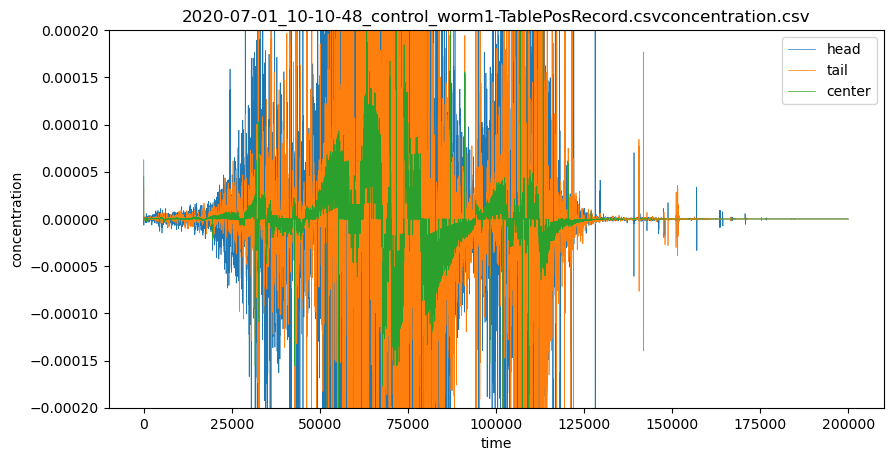

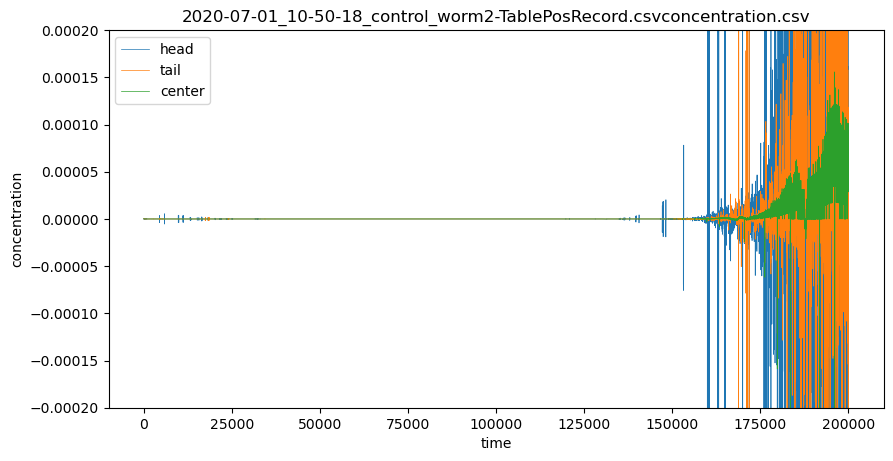

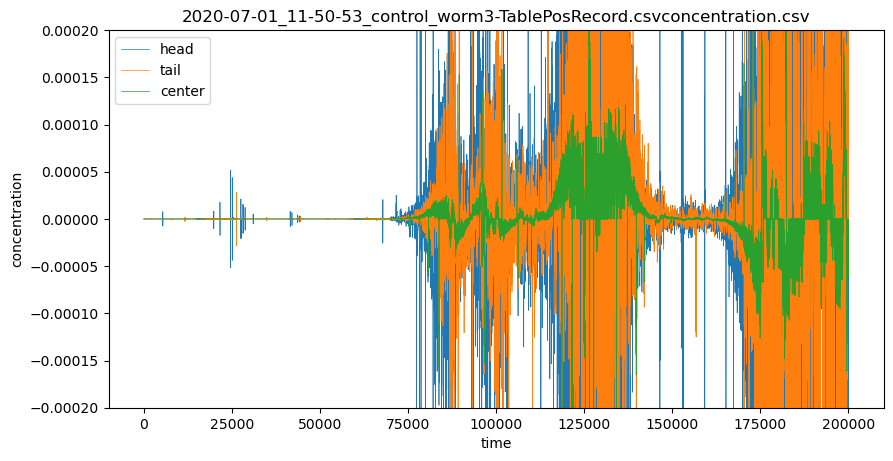

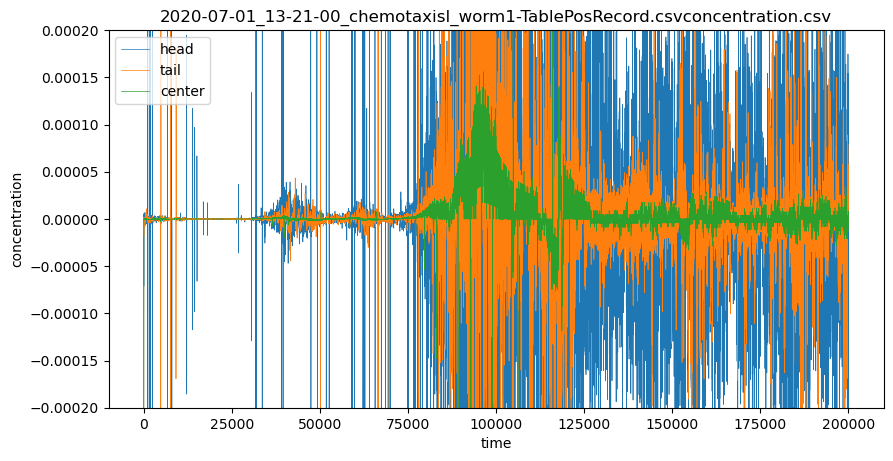

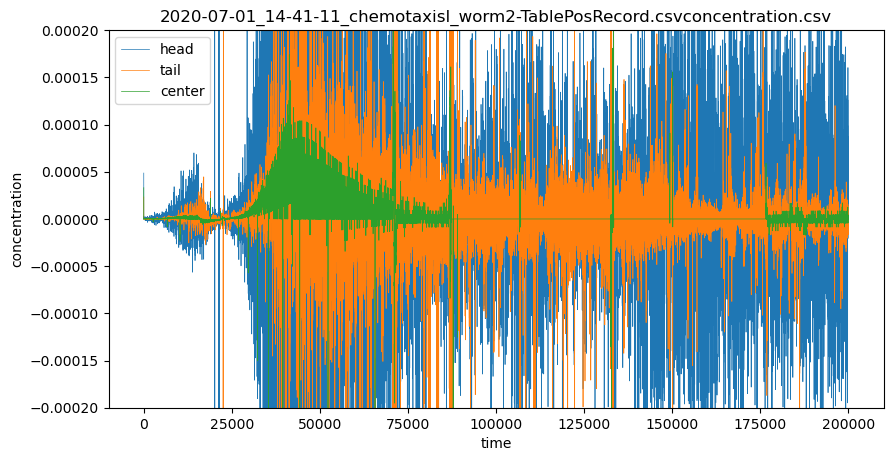

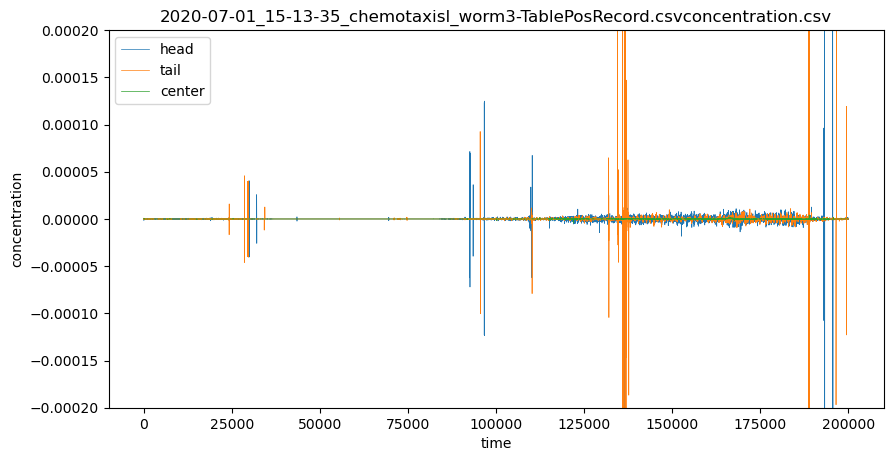

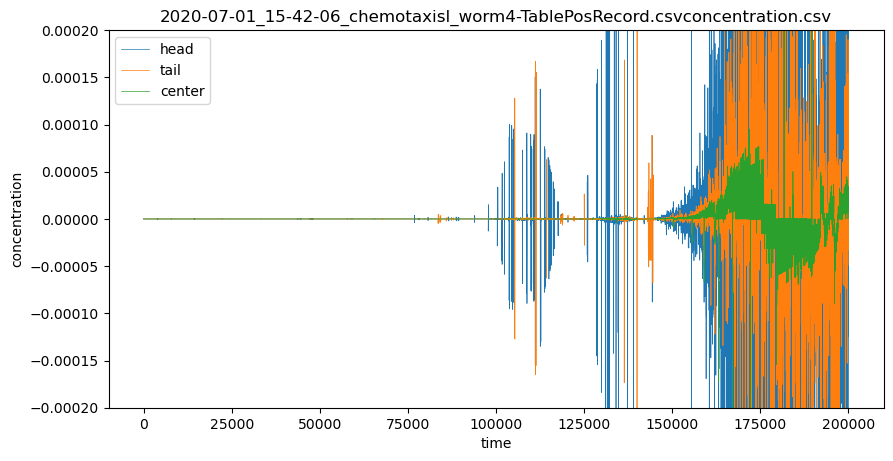

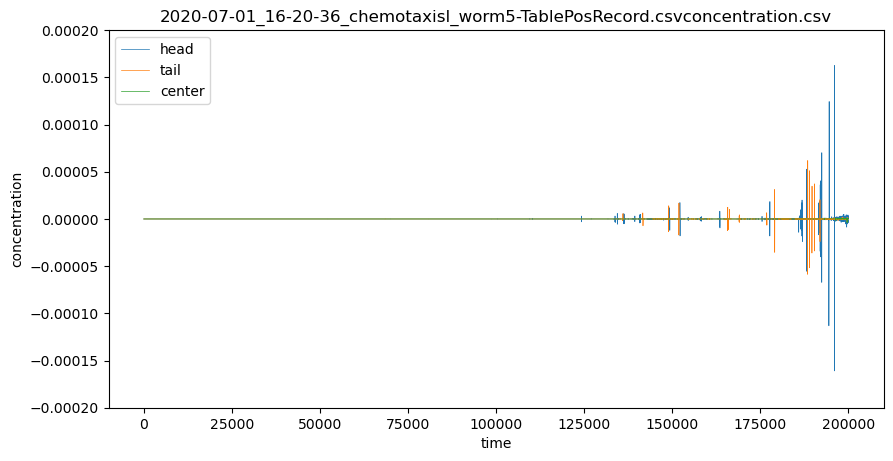

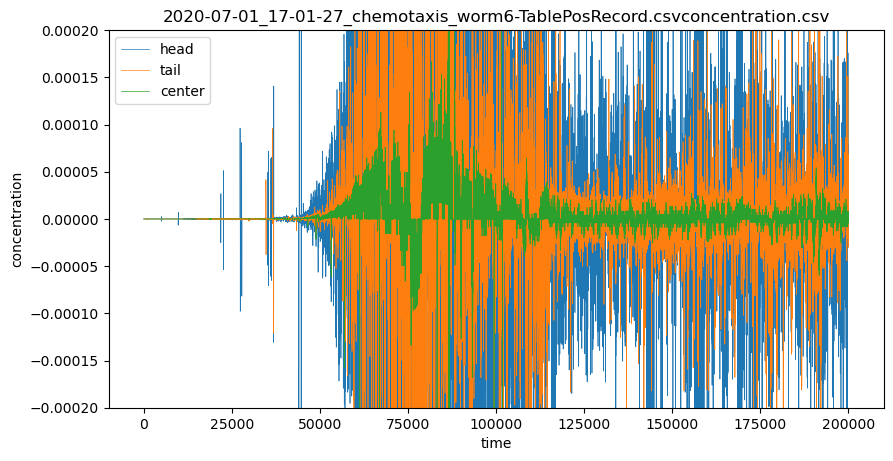

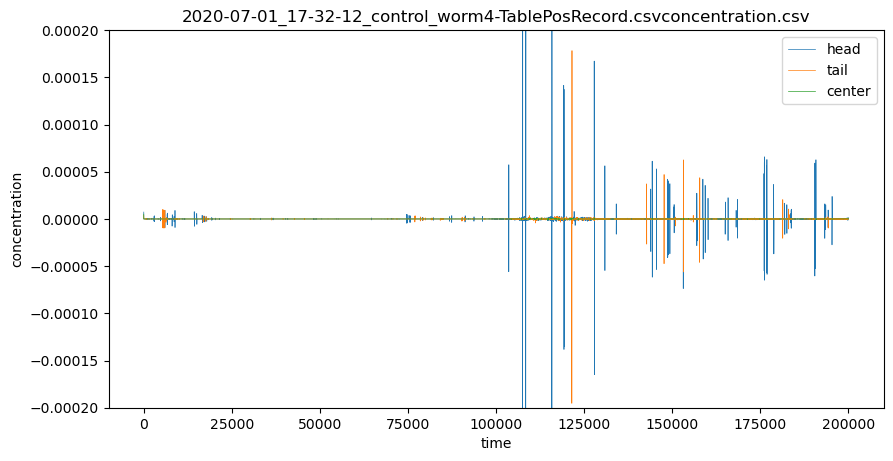

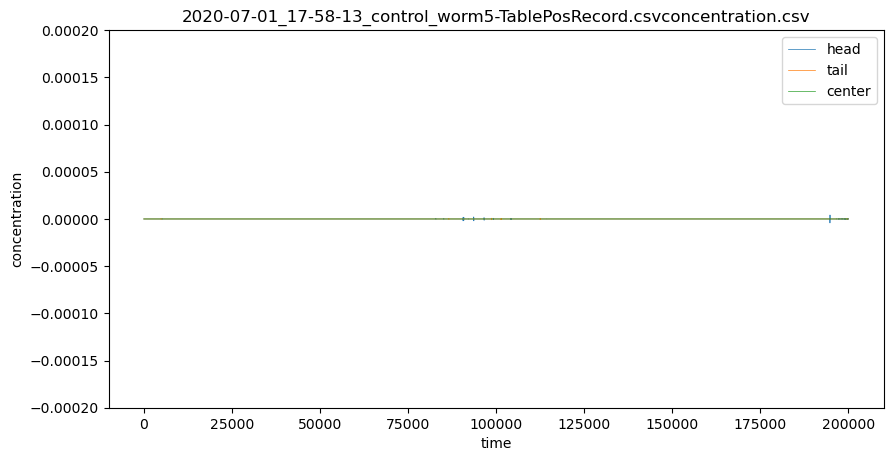

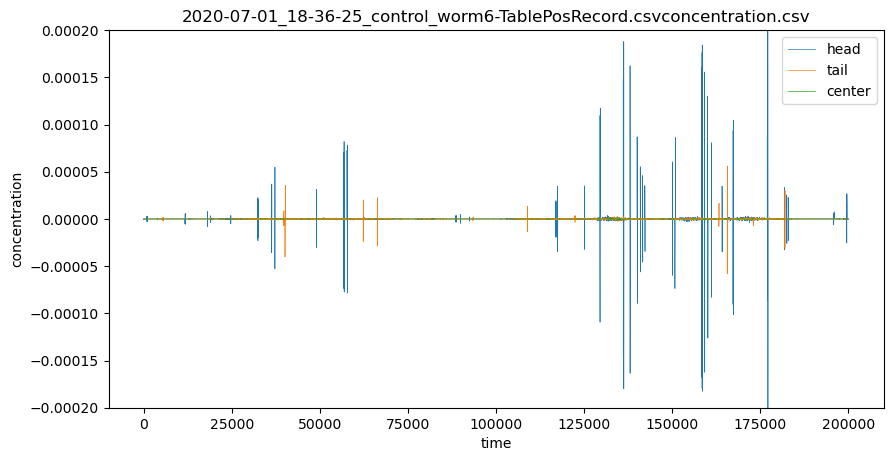

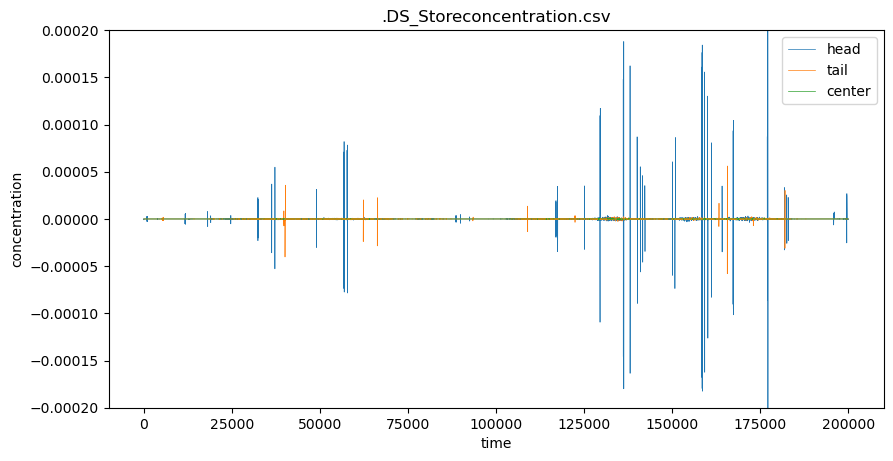

In [13]:
#concentraton and time for all tracks
path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected_concentration/'
line_width=0.5
x=np.arange(200001)

for filename in natsorted(os.listdir(path)):
    concentration_change=pd.read_csv(path+filename)
    head_conc=concentration_change['concentration_change_head']
    tail_conc=concentration_change['concentration_change_tail']
    center_conc=concentration_change['concentration_change_center']

    xfig3, ax3 = plt.subplots(1,1, figsize = (10,5), dpi=100)
    ax3.plot(x,head_conc,label="head",linewidth=line_width)
    ax3.plot(x,tail_conc,label="tail",linewidth=line_width)
    ax3.plot(x,center_conc,label="center",linewidth=line_width)
    plt.title(filename)
    plt.xlabel('time')
    plt.legend()
    plt.ylabel('concentration')
    plt.ylim([-0.0002,0.0002])
    #plt.savefig(path+filename+'.png')

In [ ]:
the_plotting_function(path,'conc')
the_plotting_function(path,'conc_change')

In [6]:
concentration_change

,Unnamed: 0,x_head_corrected,x_tail_corrected,x_center,concentration_head,concentration_tail,concentration_center,concentration_change_head,concentration_change_tail,concentration_change_center
0,0,13.962351,14.905561,14.4167,8.742200e-04,4.543922e-04,6.378814e-04,NaN,NaN,NaN
1,1,13.862682,14.801465,14.3175,9.367918e-04,4.884279e-04,6.833267e-04,6.257177e-05,3.403563e-05,4.544531e-05
2,2,13.862595,14.799063,14.3175,9.368487e-04,4.892426e-04,6.833267e-04,5.690334e-08,8.147009e-07,0.000000e+00
3,3,13.862499,14.799063,14.3175,9.369110e-04,4.892426e-04,6.833267e-04,6.232053e-08,0.000000e+00,0.000000e+00
4,4,13.861733,14.799063,14.3175,9.374090e-04,4.892426e-04,6.833267e-04,4.979396e-07,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
199996,199996,24.163553,24.393371,24.3057,7.351884e-07,6.267725e-07,6.661043e-07,5.103612e-11,-2.614224e-11,4.624037e-11
199997,199997,24.163453,24.393419,24.3056,7.352395e-07,6.267515e-07,6.661505e-07,5.103967e-11,-2.096266e-11,4.624358e-11
199998,199998,24.163253,24.394458,24.3054,7.353415e-07,6.262997e-07,6.662430e-07,1.020900e-10,-4.518559e-10,9.249679e-11
199999,199999,24.163153,24.394976,24.3053,7.353926e-07,6.260747e-07,6.662893e-07,5.105030e-11,-2.250083e-10,4.625321e-11


In [ ]:
os.mkdir('daniel')

In [ ]:
os.path.join(path, 'daniel')

In [ ]:
a='groups/zimmer'
b='myfolder'
c=a+b
print(c)

In [ ]:
os.path.exists(path_head_tail_all)

In [ ]:
os.getcwd()

In [ ]:
python_files=glob.glob('*.py')
print(python_files)

In [ ]:
for python_file in python_files:
    print(python_file)
    print('next')

In [ ]:
for element in [1,2,3,4,5, 8]:
    print(element)
    print(element/2)

In [ ]:
np.array([1,2,3,4,5, 8])/2

In [ ]:
for file in 1000.0:
    print(file)